In [56]:
import starsim
import numpy as np
import matplotlib.pyplot as plt

import copy

In [57]:
ss=starsim.StarSim(conf_file_path='/home/sophie-stucki/starsim/starsim/starsim_sun.conf')

3750.358896837229
6801.343078478975


In [58]:
ss.convolve_spec_with_filt = True #To generate ss.results['spec_lc']

In [59]:
n=400
t_sampling=np.linspace(0,ss.rotation_period,n) #sampling times
tmax=t_sampling.max() 

In [60]:
#Set ONE starspot:
ss.spot_map=np.zeros([1,15])
ss.spot_map[0][0] = 0
ss.facular_area_ratio = [1e4/3.0178179019788622]
ss.spot_map[0][1]= 0 #appearance time
ss.spot_map[0][2]=4*tmax #lifetime
ss.spot_map[0][3]=90.0 #colatitude #va de 0 a 180 #0 adalt i 90 cap a tu
ss.spot_map[0][4]=200 #longitude (0 to 360)
ss.spot_map[0][5]=0.1 #spot radius (2 to 10 aprox)


In [61]:
ss.compute_forward(observables=['lc','spec'],t=t_sampling)
results_onespot_grid = copy.deepcopy(ss.results)
#results_onespot_grid['spec_lc'] /= np.mean(results_onespot_grid['lc']) #Normalise by dividing by mean

3000.0
Date 25.05. ff_ph=100.000%. ff_sp=0.000%. ff_fc=0.000%. ff_pl=0.000%. [400/400]%%. [399/400]% 

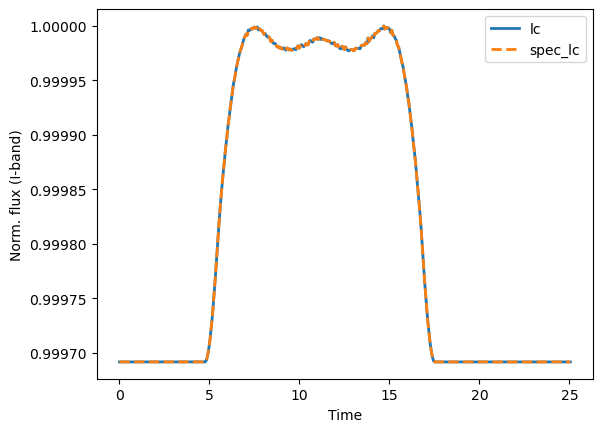

In [62]:
plt.plot(t_sampling,results_onespot_grid['lc']/np.max(results_onespot_grid['lc']),label="lc",lw=2)
plt.plot(t_sampling,results_onespot_grid['spec_lc']/np.max(results_onespot_grid['spec_lc']),label="spec_lc",lw=2,ls='dashed')
plt.xlabel("Time")
plt.ylabel("Norm. flux (I-band)")
plt.legend(fontsize=10)

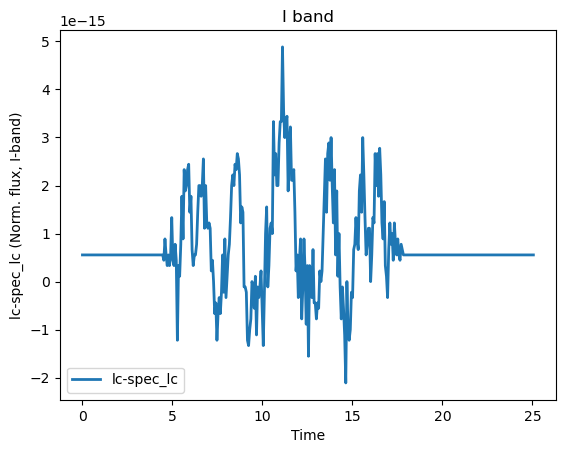

In [63]:
plt.plot(t_sampling,results_onespot_grid['lc']/np.max(results_onespot_grid['lc'])-results_onespot_grid['spec_lc']/np.max(results_onespot_grid['spec_lc']),label="lc-spec_lc",lw=2)
plt.xlabel("Time")
plt.ylabel("lc-spec_lc (Norm. flux, I-band)")
plt.title("I band")
plt.legend(fontsize=10,loc='lower left')

In [64]:
results_onespot_grid['spec'].shape

(400, 12999)

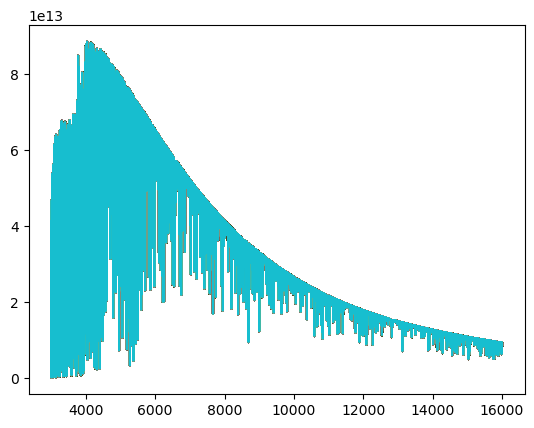

In [65]:
for i in range(len(t_sampling)):
    plt.plot(results_onespot_grid['spec_wv'],results_onespot_grid['spec'][i,:])

In [66]:
arg = np.argmin(np.abs(t_sampling-60));arg

np.int64(399)

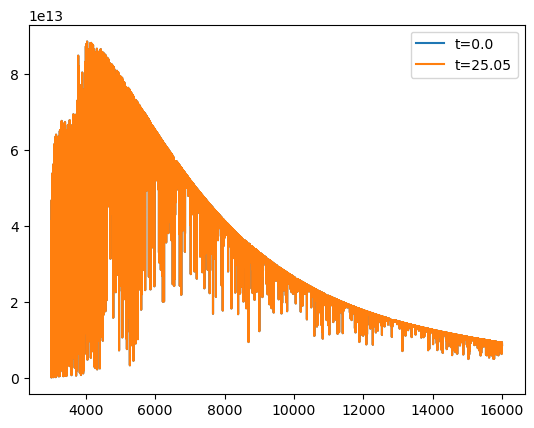

In [67]:
plt.plot(results_onespot_grid['spec_wv'],results_onespot_grid['spec'][0,:],label=f't={t_sampling[0]}')
plt.plot(results_onespot_grid['spec_wv'],results_onespot_grid['spec'][arg,:],label=f't={t_sampling[arg]:.2f}')
plt.legend()

In [68]:
from matplotlib.colors import Normalize
def plot_with_colorbar(x,y_data,z_data,xlabel=None,ylabel=None,zlabel=None,title=None,legend=False,savefig=False,savefig_path=None,alpha=1,*kwargs):
    """
    Input:
        - x: x-axis data (assumed equal for all lines)
        - y_data: y-axis data dictionary ({z : y for z in z_data})
        - z_data: colormap data
        - **kwargs: arguments to pass to plt.plot(...,**kwargs)
    Output:
        - Plot of y vs x lines coloured according to z values.
    """
    # Normalise z values to fit within [0, 1]
    norm = Normalize(vmin=np.min(z_data), vmax=np.max(z_data))
    normalised_z_data = norm(z_data)
    
    # Create a color map based on the normalised z values
    colours = plt.cm.plasma(normalised_z_data)
    
    # Plotting curves for different spot radii with varying colors
    for i, (z, y) in enumerate(y_data.items()):
        plt.plot(x, y, color=colours[i], alpha=alpha)

    # Customize plot
    if xlabel is not None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel('Time')
    if ylabel is not None:
        plt.ylabel(ylabel)
    else:
        plt.ylabel('Flux')
    if title is not None:
        plt.title(title)
    #else:
        #plt.title('Flux vs Time for Different Spot Radii (I-fast)')
    if zlabel is not None:
        plt.colorbar(plt.cm.ScalarMappable(cmap='plasma', norm=norm), label=zlabel, ax=plt.gca())  # Add color bar
    else:
        plt.colorbar(plt.cm.ScalarMappable(cmap='plasma', norm=norm), label="Spot radius", ax=plt.gca())  # Add color bar
    if legend:
        plt.legend()  # Show legend with labels
    if savefig:
        plt.savefig(savefig_path)
    plt.show()

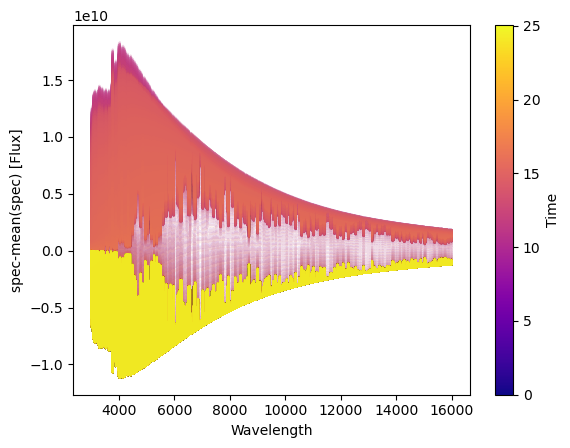

In [69]:
x = results_onespot_grid['spec_wv']
y_data = {t_sampling[i]:(results_onespot_grid['spec'][i,:]-np.mean(results_onespot_grid['spec'],axis=0)) for i in range(len(t_sampling))}
z_data = t_sampling

plot_with_colorbar(x,y_data,z_data,xlabel='Wavelength',ylabel='spec-mean(spec) [Flux]',zlabel='Time',alpha=0.1)

In [70]:
idx = np.argwhere(results_onespot_grid['spec_wv']==15000)

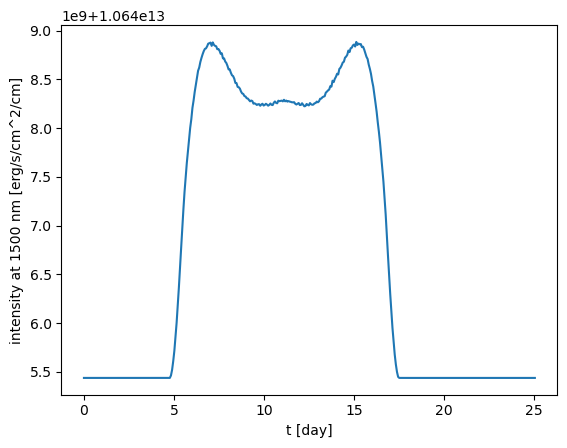

In [78]:
plt.plot(t_sampling, np.squeeze(results_onespot_grid['spec'][:,idx]))
plt.xlabel('t [day]')
plt.ylabel('intensity at 1500 nm [erg/s/cm^2/cm]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/intensity_1500_nm.png')
plt.show()

In [76]:
np.savetxt('/home/sophie-stucki/Documents/starsim_simulations/intensity_1500_nm.txt', np.transpose([t_sampling, np.squeeze(results_onespot_grid['spec'][:,idx])]))